# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows
- Show summary statistics for the dataframe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

print("Rows, columns:", df.shape)
df.head()


Rows, columns: (9404, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


In [3]:
# A describe() table hides the things that matter most here, so check them directly.
print("hotel column contains:", df["hotel"].unique().tolist())
print(f"exact duplicate rows:  {df.duplicated().sum():,} ({df.duplicated().mean():.1%})")

print("\nMissing values:")
nulls = df.isna().sum()
print(nulls[nulls > 0].to_string())

print("\nValues that shouldn't be possible:")
print(f"  adr below zero:            {(df['adr'] < 0).sum()}  (min ${df['adr'].min():.2f})")
print(f"  adr exactly zero:          {(df['adr'] == 0).sum()}")
print(f"  bookings with 0 adults:    {(df['adults'] == 0).sum()}")
print(f"  bookings with >10 adults:  {(df['adults'] > 10).sum()}  "
      f"(largest: {df['adults'].max()})")
print(f"  bookings with 0 nights:    {((df['stays_in_weekend_nights'] + df['stays_in_week_nights']) == 0).sum()}")

print("\nBookings per arrival year:")
years = df["arrival_date_year"].value_counts().sort_index()
for y, n in years.items():
    print(f"  {y}  {n:6,}  ({n / len(df):.1%})")


hotel column contains: ['Resort Hotel']
exact duplicate rows:  1,674 (17.8%)

Missing values:
country     266
agent      2335
company    8393

Values that shouldn't be possible:
  adr below zero:            1  (min $-6.38)
  adr exactly zero:          229
  bookings with 0 adults:    5
  bookings with >10 adults:  12  (largest: 55)
  bookings with 0 nights:    117

Bookings per arrival year:
  2015   8,242  (87.6%)
  2016     856  (9.1%)
  2017     306  (3.3%)


### Reflection: 
1. What stands out in the initial preview? Any columns or rows that seem unusual?

### ✍️ Your Response: 🔧

1. The `hotel` column has one value in it, Resort Hotel, on all 9,404 rows. The dictionary above describes two hotel types and lists comparing city against resort as a use case, so whatever built this extract dropped the city hotel entirely. Anything comparing the two is off the table before I start.

After that, the file is messier than `describe()` lets on. 1,674 rows, 17.8% of it, are exact duplicates. `company` is 89% empty and `agent` is 25% empty, so neither is usable as it stands. `adr` runs down to -$6.38, which isn't a price, and another 229 bookings sit at exactly $0. One booking lists 55 adults and twelve list more than ten. 117 bookings cover zero nights, which isn't a stay. The years are lopsided too: 87.6% of arrivals are 2015 against 9.1% in 2016 and 3.3% in 2017, so this is really a 2015 snapshot with a tail, not three years of history.


## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- 2.1 Choose 3–5 numeric features related to customer behavior
- 2.2 Perform basic data preparation - remove outliers, remove duplicates, correct any datatypes that need adjustment
- 2.3 Drop missing values if needed
- 2.4 Standardize using `StandardScaler` for any large values  (over 100)

In [4]:
# 2.1 Five numeric features, all of them things a guest chooses.
#     is_canceled is deliberately left out. It gets used later to check the
#     clusters against something the model never saw.
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

features = ["lead_time", "total_nights", "adr", "total_guests", "total_of_special_requests"]

# 2.2 / 2.3 Cleaning, one filter at a time so the cost of each is visible.
clean = df.copy()
print(f"start                       {len(clean):6,}")
clean = clean.drop_duplicates()
print(f"drop exact duplicates       {len(clean):6,}")
clean = clean[clean["adr"] > 0]
print(f"drop adr of zero or less    {len(clean):6,}")
clean = clean[clean["total_nights"].between(1, 21)]
print(f"keep stays of 1 to 21 nights{len(clean):6,}")
clean = clean[clean["total_guests"].between(1, 10)]
print(f"keep parties of 1 to 10     {len(clean):6,}")
clean = clean[clean["adr"] < 400]
print(f"drop the one adr above 400  {len(clean):6,}")

clean = clean.dropna(subset=features).reset_index(drop=True)
print(f"\nkept {len(clean) / len(df):.1%} of the original file")
print(clean[features].describe().round(2).to_string())


start                        9,404
drop exact duplicates        7,730
drop adr of zero or less     7,511
keep stays of 1 to 21 nights 7,499
keep parties of 1 to 10      7,498
drop the one adr above 400   7,497

kept 79.7% of the original file
       lead_time  total_nights      adr  total_guests  total_of_special_requests
count    7497.00       7497.00  7497.00       7497.00                    7497.00
mean       64.42          4.36    93.53          1.96                       0.69
std        74.77          3.18    53.91          0.68                       0.86
min         0.00          1.00     2.00          1.00                       0.00
25%         6.00          2.00    48.00          2.00                       0.00
50%        38.00          4.00    79.00          2.00                       0.00
75%        93.00          7.00   130.00          2.00                       1.00
max       532.00         21.00   367.00          5.00                       5.00


In [5]:
# 2.4 The instruction says to scale values over 100, which here is lead_time and
# adr only. I scaled all five instead. The cell below is why.
X = StandardScaler().fit_transform(clean[features])
X_scaled = pd.DataFrame(X, columns=features)
X_scaled.head()


,lead_time,total_nights,adr,total_guests,total_of_special_requests
0,-0.767916,-1.054436,-0.343654,-1.418807,-0.805815
1,-0.687667,-1.054436,-0.343654,-1.418807,-0.805815
2,-0.674293,-0.740405,0.082998,0.051989,0.359989
3,-0.861539,-0.740405,0.249949,0.051989,-0.805815
4,-0.741166,-0.740405,0.175749,0.051989,0.359989


In [6]:
# Scaling only the two big columns leaves total_nights (max 21) in raw units,
# and raw units are exactly what KMeans measures distance in.
partial = clean[features].copy().astype(float)
partial[["lead_time", "adr"]] = StandardScaler().fit_transform(partial[["lead_time", "adr"]])

for name, data in [("all five scaled", X_scaled), ("only lead_time and adr scaled", partial)]:
    labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(data)
    spread = data.assign(c=labels).groupby("c").mean().std()
    print(f"--- {name} ---")
    print("  how far apart the cluster centers sit on each feature:")
    print("  " + spread.round(3).to_string().replace("\n", "\n  "))
    print(f"  silhouette {silhouette_score(data, labels):.4f}")
    print("  cluster means, real units:")
    print("  " + clean.assign(c=labels).groupby("c")[features].mean().round(1)
                     .to_string().replace("\n", "\n  "))
    print()


--- all five scaled ---
  how far apart the cluster centers sit on each feature:
  lead_time                    0.806
  total_nights                 0.671
  adr                          0.797
  total_guests                 0.583
  total_of_special_requests    1.076


  silhouette 0.2715
  cluster means, real units:
     lead_time  total_nights    adr  total_guests  total_of_special_requests
  c                                                                         
  0       64.6           4.6  113.2           2.2                        2.3
  1       18.0           2.3   55.9           1.6                        0.3
  2       47.9           4.5  155.1           2.5                        0.5
  3      157.7           7.5   80.3           1.9                        0.4

--- only lead_time and adr scaled ---
  how far apart the cluster centers sit on each feature:
  lead_time                    0.589
  total_nights                 4.581
  adr                          0.362
  total_guests                 0.206
  total_of_special_requests    0.173


  silhouette 0.3267
  cluster means, real units:
     lead_time  total_nights    adr  total_guests  total_of_special_requests
  c                                                                         
  0       97.7           7.0  107.8           2.1                        0.8
  1       22.5           1.5   68.9           1.7                        0.5
  2      126.6          12.1   97.8           2.0                        0.7
  3       75.0           3.9  112.5           2.1                        0.9



### Reflection: 
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?

### ✍️ Your Response: 🔧

1. `lead_time`, `total_nights`, `adr`, `total_guests` and `total_of_special_requests`. I built nights and guests by adding the weekend and weekday columns and the adults, children and babies columns, since a stay is a stay and a party is a party. Each one is a decision the guest made: when to book, how long to stay, what to pay, who to bring, how much to ask for. I left `is_canceled` out on purpose even though it's numeric, because it's an outcome rather than a behavior. That makes it a fair test of the clusters in part 6.

On scaling, the instruction says to standardize values over 100, which here is `lead_time` and `adr` only. I scaled all five, and the cell above is why. Leave `total_nights` in raw units and its cluster centers spread 4.58 against 0.17 to 0.59 for everything else, so KMeans splits on length of stay and ignores the rest. Those clusters come back at 1.5, 3.9, 7.0 and 12.1 nights with price and party size almost flat across them. Its silhouette is actually the better of the two, 0.3267 against 0.2715, which is a useful reminder that a clean score and a useful answer aren't the same thing.

2. I'd expect a short cheap last-minute group, a family or group booking with more guests and a bigger bill, and a planner booking months out. Whether special requests separate anybody is the part I'm least sure about.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign a cluster number to each guest
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

In [7]:
# Try a range of k before picking one.
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    rows.append({"k": k,
                 "WCSS": round(km.inertia_, 1),
                 "silhouette": round(silhouette_score(X, km.labels_), 4),
                 "davies_bouldin": round(davies_bouldin_score(X, km.labels_), 4)})

print(pd.DataFrame(rows).to_string(index=False))


 k    WCSS  silhouette  davies_bouldin
 2 28377.2      0.2372          1.6006
 3 22968.6      0.2620          1.5013
 4 19959.5      0.2715          1.4019
 5 17748.1      0.2502          1.3276
 6 15819.7      0.2617          1.2811
 7 14155.3      0.2633          1.2278
 8 13237.3      0.2705          1.2899


In [8]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clean["kmeans_cluster"] = kmeans.fit_predict(X)

print(clean["kmeans_cluster"].value_counts().sort_index().to_string())


kmeans_cluster
0    1156
1    2861
2    1750
3    1730


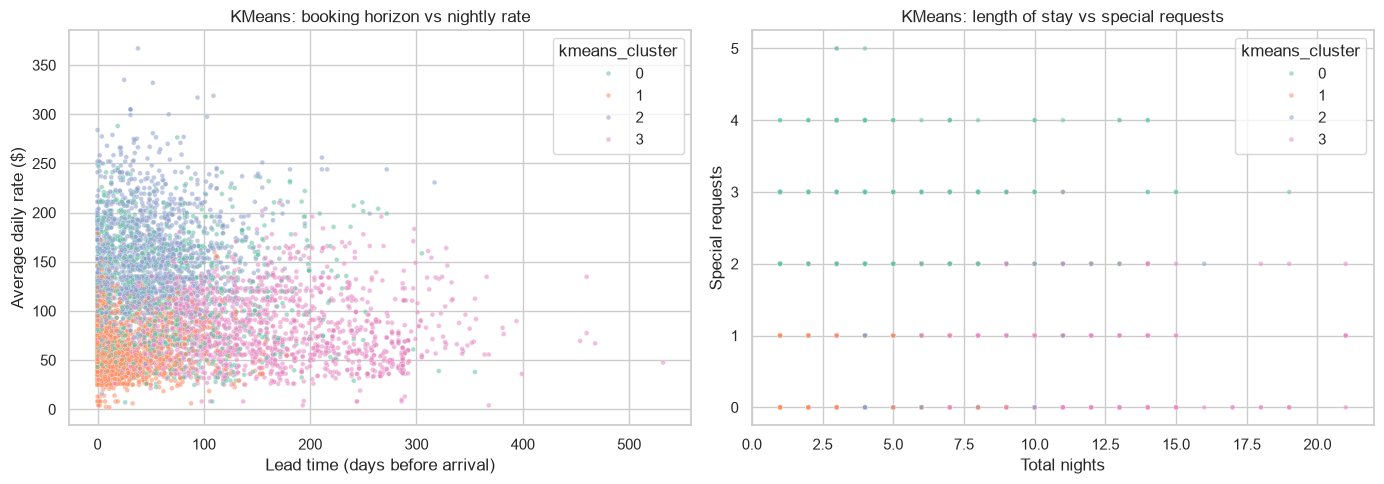

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=clean, x="lead_time", y="adr", hue="kmeans_cluster",
                palette="Set2", s=12, alpha=0.55, ax=axes[0], legend="full")
axes[0].set_title("KMeans: booking horizon vs nightly rate")
axes[0].set_xlabel("Lead time (days before arrival)")
axes[0].set_ylabel("Average daily rate ($)")

sns.scatterplot(data=clean, x="total_nights", y="total_of_special_requests",
                hue="kmeans_cluster", palette="Set2", s=12, alpha=0.55,
                ax=axes[1], legend="full")
axes[1].set_title("KMeans: length of stay vs special requests")
axes[1].set_xlabel("Total nights")
axes[1].set_ylabel("Special requests")

plt.tight_layout()
plt.show()


In [10]:
kmeans_profile = clean.groupby("kmeans_cluster")[features].mean().round(2)
kmeans_profile["bookings"] = clean["kmeans_cluster"].value_counts().sort_index()
print(kmeans_profile.to_string())


                lead_time  total_nights     adr  total_guests  total_of_special_requests  bookings
kmeans_cluster                                                                                    
0                   64.65          4.55  113.22          2.22                       2.26      1156
1                   18.02          2.27   55.90          1.56                       0.34      2861
2                   47.86          4.55  155.06          2.48                       0.49      1750
3                  157.74          7.48   80.34          1.93                       0.44      1730


### Reflection: 
1. What `k` value did you choose, and how did you decide?

2. For each cluster answer the following - what types of customers seem to show up in the cluster?  which variables are most prominent or important for that cluster?

### ✍️ Your Response: 🔧

1. k=4. I ran 2 through 8 first. WCSS falls the whole way, which it always does, so it can't pick k. Silhouette peaks at 0.2715 at k=4 and drops at k=5, and Davies-Bouldin improves steadily to 1.4019 there. k=8 nearly ties on silhouette at 0.2705, but eight segments is more than a marketing manager can run campaigns against, and the brief asked for a few clear types. One thing worth saying plainly: 0.27 is a weak silhouette. These aren't four separated islands. They're a partition of one continuous cloud, and I'd rather say that than dress it up.

2. **Cluster 1, 2,861 bookings.** The biggest group. Books 18 days out, stays 2.3 nights, pays $55.90, 1.6 guests, barely any requests. Short cheap trips. Lead time and rate define it, both the lowest of the four.

**Cluster 2, 1,750 bookings.** Pays $155.06, nearly triple cluster 1, over 4.6 nights with 2.5 guests. Rate is the whole story, and party size is the highest of the four.

**Cluster 3, 1,730 bookings.** Books 158 days ahead and stays 7.5 nights at $80.34. Lead time is the standout, more than double anyone else, and it's also the longest stay.

**Cluster 0, 1,156 bookings.** Averages 2.26 special requests where every other cluster sits under 0.5. That single variable is basically the entire cluster, and it's the one I didn't expect to separate anybody.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

In [11]:
gmm = GaussianMixture(n_components=K, random_state=42)
gmm.fit(X)

# Soft clustering: a probability of belonging to every component, not one label.
proba = gmm.predict_proba(X)
proba_df = pd.DataFrame(proba, columns=[f"p_cluster_{i}" for i in range(K)]).round(3)
proba_df["assigned"] = proba.argmax(axis=1)
proba_df["confidence"] = proba.max(axis=1).round(3)

clean["gmm_cluster"] = proba.argmax(axis=1)
print(clean["gmm_cluster"].value_counts().sort_index().to_string())
print("\nMembership probabilities for the first few bookings:")
proba_df.head()


gmm_cluster
0    5018
1     568
2     590
3    1321

Membership probabilities for the first few bookings:


,p_cluster_0,p_cluster_1,p_cluster_2,p_cluster_3,assigned,confidence
0,0.0,0.0,0.0,1.0,3,1.0
1,0.0,0.0,0.0,1.0,3,1.0
2,1.0,0.0,0.0,0.0,0,1.0
3,1.0,0.0,0.0,0.0,0,1.0
4,1.0,0.0,0.0,0.0,0,1.0


In [12]:
# How soft is the soft clustering, really?
confidence = proba.max(axis=1)
print(f"Mean probability of the winning cluster: {confidence.mean():.3f}")
for t in (0.90, 0.80, 0.60):
    print(f"  assigned above {t:.0%} confidence: {(confidence > t).sum():5,} ({(confidence > t).mean():.1%})")
print(f"  genuinely undecided (under 60%):  {(confidence < 0.60).sum():5,} "
      f"({(confidence < 0.60).mean():.1%})")


Mean probability of the winning cluster: 0.987
  assigned above 90% confidence: 7,217 (96.3%)
  assigned above 80% confidence: 7,316 (97.6%)
  assigned above 60% confidence: 7,424 (99.0%)
  genuinely undecided (under 60%):     73 (1.0%)


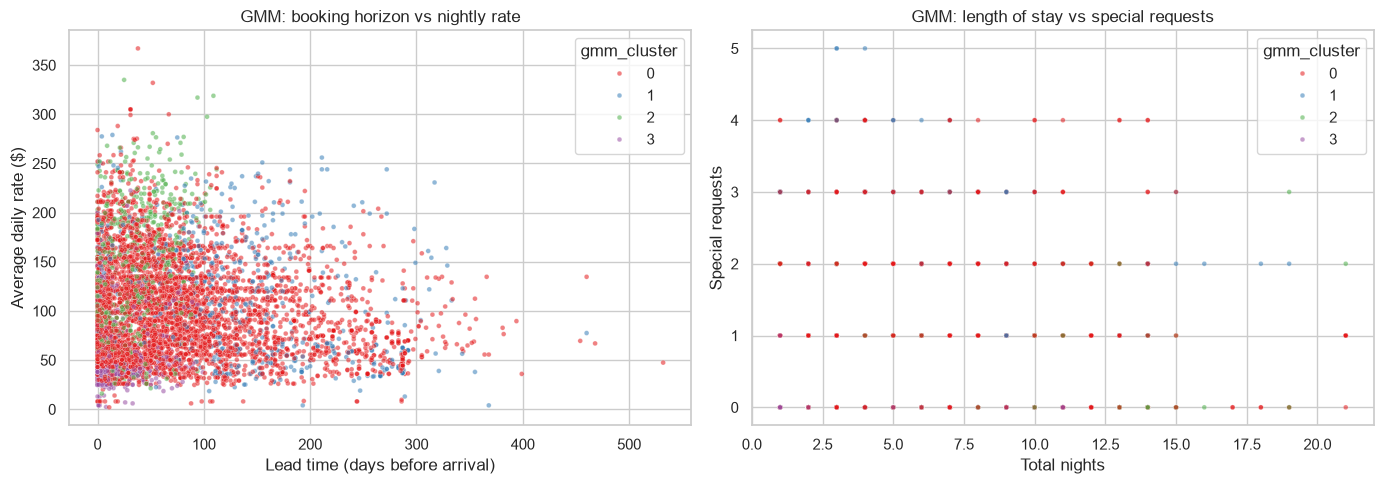

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=clean, x="lead_time", y="adr", hue="gmm_cluster",
                palette="Set1", s=12, alpha=0.55, ax=axes[0], legend="full")
axes[0].set_title("GMM: booking horizon vs nightly rate")
axes[0].set_xlabel("Lead time (days before arrival)")
axes[0].set_ylabel("Average daily rate ($)")

sns.scatterplot(data=clean, x="total_nights", y="total_of_special_requests",
                hue="gmm_cluster", palette="Set1", s=12, alpha=0.55,
                ax=axes[1], legend="full")
axes[1].set_title("GMM: length of stay vs special requests")
axes[1].set_xlabel("Total nights")
axes[1].set_ylabel("Special requests")

plt.tight_layout()
plt.show()


In [14]:
gmm_profile = clean.groupby("gmm_cluster")[features].mean().round(2)
gmm_profile["bookings"] = clean["gmm_cluster"].value_counts().sort_index()
print(gmm_profile.to_string())

# The party-size means look suspiciously round, so check the range behind them.
print("\ntotal_guests within each GMM cluster:")
print(clean.groupby("gmm_cluster")["total_guests"].agg(["min", "max", "nunique"]).to_string())


             lead_time  total_nights     adr  total_guests  total_of_special_requests  bookings
gmm_cluster                                                                                    
0                73.18          4.73   96.64          2.00                       0.72      5018
1               140.30          5.43  115.32          2.51                       1.48       568
2                34.04          4.96  141.19          3.30                       0.64       590
3                12.07          2.23   51.02          1.00                       0.27      1321

total_guests within each GMM cluster:
             min  max  nunique
gmm_cluster                   
0              2    2        1
1              1    5        4
2              1    5        4
3              1    1        1


### Reflection: 
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?

### ✍️ Your Response: 🔧

1. It split on party size, almost entirely. GMM cluster 0 holds 5,018 bookings where `total_guests` is exactly 2, minimum 2 and maximum 2, and cluster 3 holds 1,321 that are all exactly 1. `total_guests` only takes the values 1 through 5, and a Gaussian fitted to a count variable collapses onto those spikes. That's also why the soft clustering came back barely soft: the mean winning probability is 0.987, and only 73 bookings, 1.0% of the file, land under 60% confidence. KMeans spread its groups across price, lead time and special requests instead, which tells me more.

2. GMM earns its keep when the question is about uncertainty rather than assignment. Which guests sit on the line between two segments, so a campaign aimed at one might also land on them. How sure are we about this label before we spend money on it. It also handles clusters that are stretched or different sizes, which KMeans can't, since KMeans assumes round blobs of similar size. None of that paid off here, mostly because I handed it a discrete variable it was the wrong tool for.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- 5.1 Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index 

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

In [15]:
# GMM has no .inertia_, so WCSS gets computed the same way for both models:
# squared distance from each booking to the center of the cluster it landed in.
def wcss(data, labels):
    data = np.asarray(data)
    return float(sum(((data[labels == c] - data[labels == c].mean(axis=0)) ** 2).sum()
                     for c in np.unique(labels)))

# 7,497 rows scores in a couple of seconds, so no sampling needed here.
scores = []
for name, labels in [("KMeans", clean["kmeans_cluster"]), ("GMM", clean["gmm_cluster"])]:
    scores.append({"model": name,
                   "WCSS": round(wcss(X, labels.values), 1),
                   "silhouette": round(silhouette_score(X, labels), 4),
                   "davies_bouldin": round(davies_bouldin_score(X, labels), 4)})

print(pd.DataFrame(scores).to_string(index=False))
print("\nLower WCSS is better, higher silhouette is better, lower Davies-Bouldin is better.")


 model    WCSS  silhouette  davies_bouldin
KMeans 19959.5      0.2715          1.4019
   GMM 27827.7      0.1521          2.3323

Lower WCSS is better, higher silhouette is better, lower Davies-Bouldin is better.


In [16]:
# Worth knowing before reading too much into that table: KMeans is built to
# minimize WCSS, and silhouette and Davies-Bouldin are both distance based too.
# GMM maximizes likelihood instead, so all three metrics are playing KMeans' game.
print("On GMM's own measure, lower is better:")
print(f"  BIC {gmm.bic(X):,.1f}")
print(f"  AIC {gmm.aic(X):,.1f}")
print(f"  average log-likelihood per booking {gmm.score(X):.4f}")


On GMM's own measure, lower is better:
  BIC 15,938.4
  AIC 15,363.8
  average log-likelihood per booking -1.0136


### Reflection: 
5.2. Which model performed better on the metrics?

5.3. Would you recommend KMeans or GMM for a business analyst? Why?

### ✍️ Your Response: 🔧

**5.2.** KMeans, on all three. WCSS 19,959.5 against 27,827.7, silhouette 0.2715 against 0.1521, Davies-Bouldin 1.4019 against 2.3323. A clean sweep, but the test is rigged and it's worth saying so. KMeans is built to minimize WCSS, and silhouette and Davies-Bouldin are distance based too, so all three are scoring GMM on the exact thing KMeans optimizes. GMM maximizes likelihood instead, and on its own measure it reports a BIC of 15,938.4. A fair head to head would compare BIC across GMMs at different k, not WCSS across two different kinds of model.

**5.3.** KMeans, for this analyst and this question. It's faster, the output is one cluster number per guest, and "these 2,861 guests book two nights, 18 days ahead, at $56" is a sentence you can say out loud in a meeting. GMM hands back a probability across four columns for every guest, which is more honest and much harder to give a marketing team. I'd reach for GMM when somebody asks how sure we are about a borderline customer, not when they want segments to email on Monday.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

In [17]:
# Sorted by nightly rate so the segments read in order.
profile = (clean.groupby("kmeans_cluster")
                .agg(bookings=("adr", "size"),
                     avg_lead_time=("lead_time", "mean"),
                     avg_nights=("total_nights", "mean"),
                     avg_adr=("adr", "mean"),
                     avg_guests=("total_guests", "mean"),
                     avg_requests=("total_of_special_requests", "mean"))
                .round(2)
                .sort_values("avg_adr"))
print(profile.to_string())


                bookings  avg_lead_time  avg_nights  avg_adr  avg_guests  avg_requests
kmeans_cluster                                                                        
1                   2861          18.02        2.27    55.90        1.56          0.34
3                   1730         157.74        7.48    80.34        1.93          0.44
0                   1156          64.65        4.55   113.22        2.22          2.26
2                   1750          47.86        4.55   155.06        2.48          0.49


In [18]:
# is_canceled was never an input, so it's a fair test of whether the segments
# describe anything real.
check = (clean.groupby("kmeans_cluster")
              .agg(bookings=("is_canceled", "size"),
                   cancel_rate=("is_canceled", "mean"),
                   repeat_guest_rate=("is_repeated_guest", "mean"),
                   avg_revenue_per_booking=("adr", lambda s: (s * clean.loc[s.index, "total_nights"]).mean()))
              .round(3)
              .sort_values("cancel_rate"))
print(check.to_string())


                bookings  cancel_rate  repeat_guest_rate  avg_revenue_per_booking
kmeans_cluster                                                                   
1                   2861        0.105              0.165                  128.203
0                   1156        0.196              0.067                  545.323
3                   1730        0.228              0.023                  612.432
2                   1750        0.238              0.025                  715.313


### Reflection: 
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?

### ✍️ Your Response: 🔧

1. Sorted by rate they read as four fairly ordinary hotel guests. At $55.90 there's the short-notice budget trip, booked 18 days out for 2.3 nights by 1.6 people, which is a weekend getaway. At $80.34 there are the planners, booking 158 days ahead for a 7.5 night holiday. At $113.22 there's the high-touch guest, paying above average and averaging 2.26 special requests. At $155.06 there's the premium stay, 4.6 nights and 2.5 guests, most likely peak season.

The part that convinced me they're real is cancellation rate, which was never an input. The budget group cancels at 10.5% while the other three run 19.6% to 23.8%. Repeat guests go the same way, 16.5% for the budget group against 2.3% for the planners.

2. The budget group is worth more than its $128 average booking suggests, since it cancels half as often and comes back seven times more. I'd put it on a loyalty or direct-booking offer rather than discount it further. The planners book 158 days out at 22.8% cancellation and 2.3% repeat, so that's a deposit or a flexible-rate upsell, not a marketing problem. Cluster 0 is operational rather than promotional: 1,156 guests averaging 2.26 requests each means front desk staffing and a pre-arrival form would do more for them than any email. The premium group is where an upsell pays best at $715 a booking, but it also cancels most at 23.8%, so overbooking should account for it.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### Reflection: 
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧

1. There's no answer key, so you can't tell a real pattern from a convenient one. Every check I have is circular. Silhouette says my clusters are tight, and tight is exactly what KMeans was trying to make them. It clicked during the scaling test in part 2, where the worse segmentation scored the better silhouette. The only real confidence I got came from checking the clusters against cancellation rate, which the model never saw.

2. When there's no label, or when the label you have isn't the question. I could have thrown a classifier at `is_canceled` here and gotten a number, but "who are our guests" isn't a prediction, it's a description. Clustering also earns its place as a first look at a market nobody has mapped yet, which is roughly where a hotel sits when it opens somewhere new.

3. It sorts the customer list into a handful of groups where people inside a group behave alike, and the computer picks the groups instead of us guessing at them. I'd skip the method entirely and show the table: four groups, here's what each one pays, how far ahead they book, how often they cancel. Then the honest part, which is that the lines between groups are soft. Use them to aim a campaign, don't treat them as a fact about any one person.

4. Both of my outcomes are marketing analytics. The first is using Python to prepare customer data well enough to build segments and judge whether a campaign worked, and this is that from end to end: pick behavioral features, clean, scale, cluster, then test the result against something the model never saw. The second is turning that into recommendations while handling privacy, bias and the ethical limits of consumer data, and the bias part is live here. These clusters come from one resort, the file is 87.6% 2015 bookings, and I dropped a fifth of the rows to get them. Any promotion built on these segments inherits all of that. A segment is also a label the guest never agreed to and can't see, so "high cancellation risk" needs to shape a deposit policy, not quietly turn into a worse offer for the same person.


## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [19]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"

[NbConvertApp] Converting notebook assignment_09_clustering.ipynb to html


[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).


[NbConvertApp] Writing 910867 bytes to assignment_09_clustering.html
